In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
SHEAR_LEN = 1080
NUM_SRC_BINS = 8
NUM_SHEAR_2PCFS = 72 # 8 bins -> 36 xip and 36 xim

ARCMIN_TO_RAD = 2.90888208665721580e-4
RAD_TO_ARCMIN = 1/ARCMIN_TO_RAD
THETA_MIN_ARCMIN  = 2.5   # Minimum angular scale (in arcminutes)
THETA_MAX_ARCMIN  = 250.  # Maximum angular scale (in arcminutes)
NUM_ANG_BINS = 15         # Number of angular bins

THETA_MIN_RAD = THETA_MIN_ARCMIN * ARCMIN_TO_RAD
THETA_MAX_RAD = THETA_MAX_ARCMIN * ARCMIN_TO_RAD
DLOG_THETA = (np.log(THETA_MAX_RAD) - np.log(THETA_MIN_RAD))/NUM_ANG_BINS
theta = np.zeros(NUM_ANG_BINS)

for i in range(NUM_ANG_BINS):
    THETA_MIN_BIN = np.exp(np.log(THETA_MIN_RAD) + i * DLOG_THETA)
    THETA_MAX_BIN = np.exp(np.log(THETA_MIN_RAD) + (i + 1) * DLOG_THETA)
    theta[i] = (2/3) * (THETA_MAX_BIN**3 - THETA_MIN_BIN**3) / (THETA_MAX_BIN**2 - THETA_MIN_BIN**2)

theta *= RAD_TO_ARCMIN

In [20]:
dv_nobaryons = np.loadtxt("NOBARYONS.modelvector", usecols=1, max_rows=SHEAR_LEN)
dv_bahamas   = np.loadtxt("BASELINE.modelvector", usecols=1, max_rows=SHEAR_LEN)
dv_owls      = np.loadtxt("STRONGBARYONS.modelvector", usecols=1, max_rows=SHEAR_LEN)
dvs_antilles = []
for i in range(1, 401):
    dv = np.loadtxt(f"antilles_dvs/antilles-{i}.modelvector", usecols=1, max_rows=SHEAR_LEN)
    dvs_antilles.append(dv)
dvs_antilles = np.array(dvs_antilles)

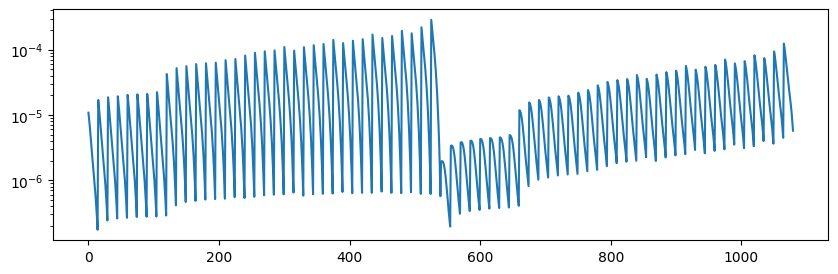

In [4]:
# Plot full dv
fig = plt.figure(figsize=(10, 3))
plt.semilogy(dv_nobaryons)

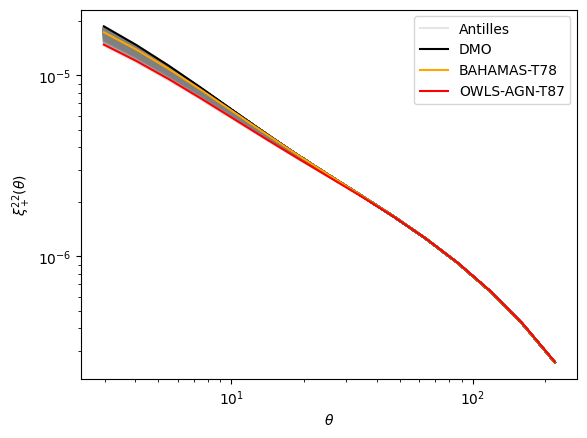

In [83]:
# Plot only (2, 2)
dv_nobaryons_22 = dv_nobaryons[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
dv_bahamas_22 = dv_bahamas[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
dv_owls_22 = dv_owls[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
for i, dv in enumerate(dvs_antilles):
    dv_antilles_22 = dv[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
    plt.loglog(theta, dv_antilles_22, color="gray", alpha=0.2, label="Antilles" if i == 0 else "")
plt.loglog(theta, dv_nobaryons_22, color="black", label="DMO")
plt.loglog(theta, dv_bahamas_22, color="orange", label="BAHAMAS-T78")
plt.loglog(theta, dv_owls_22, color="red", label="OWLS-AGN-T87")
plt.xlabel("$\\theta$")
plt.ylabel("$\\xi^{22}_+(\\theta)$")
plt.legend()

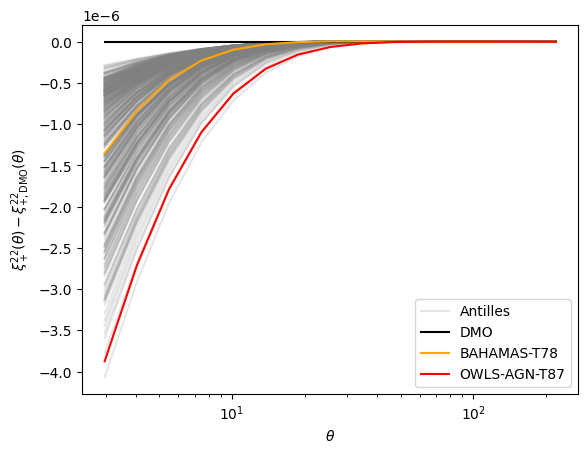

In [85]:
# Plot only (2, 2), difference between Antilles and DMO
dv_nobaryons_22 = dv_nobaryons[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
for i, dv in enumerate(dvs_antilles):
    dv_antilles_22 = dv[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
    plt.semilogx(theta, dv_antilles_22 - dv_nobaryons_22, color="gray", alpha=0.2, label="Antilles" if i == 0 else "")
plt.semilogx(theta, dv_nobaryons_22 - dv_nobaryons_22, color="black", label="DMO")
plt.semilogx(theta, dv_bahamas_22 - dv_nobaryons_22, color="orange", label="BAHAMAS-T78")
plt.semilogx(theta, dv_owls_22 - dv_nobaryons_22, color="red", label="OWLS-AGN-T87")
plt.xlabel("$\\theta$")
plt.ylabel("$\\xi^{22}_+(\\theta) - \\xi^{22}_{+, \\mathrm{DMO}}(\\theta)$")
plt.legend()

In [96]:
# Compute PCA
diffs = np.array([dv - dv_nobaryons for dv in dvs_antilles])

pca = PCA(n_components=4)
pca.fit(diffs)
pca.mean_ = 0*dv_nobaryons # NOTE: this is important to map dv_nobaryons to (0) in Q-space

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Q_antilles  = pca.transform(diffs)
Q_nobaryons = pca.transform([dv_nobaryons - dv_nobaryons, ])
Q_bahamas   = pca.transform([dv_bahamas - dv_nobaryons, ])
Q_owls      = pca.transform([dv_owls - dv_nobaryons, ])

Explained variance ratio: [9.69330113e-01 2.94958484e-02 9.95875125e-04 1.02541541e-04]


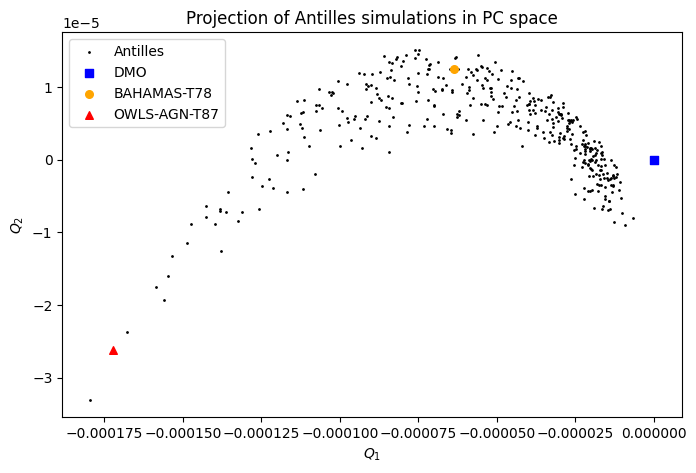

In [97]:
# Projection of Antilles simulations in PC space, see Figure 2 of https://arxiv.org/pdf/2510.25596
fig = plt.figure(figsize=(8, 5))
plt.scatter(Q_antilles[:, 0], Q_antilles[:, 1], s=1, c="black", label="Antilles")
plt.scatter(Q_nobaryons[:, 0], Q_nobaryons[:, 1], s=30, c="blue", marker="s", label="DMO")
plt.scatter(Q_bahamas[:, 0], Q_bahamas[:, 1], s=30, c="orange", marker="o", label="BAHAMAS-T78")
plt.scatter(Q_owls[:, 0], Q_owls[:, 1], s=30, c="red", marker="^", label="OWLS-AGN-T87")
plt.xlabel("$Q_1$")
plt.ylabel("$Q_2$")
plt.title("Projection of Antilles simulations in PC space")
plt.legend()

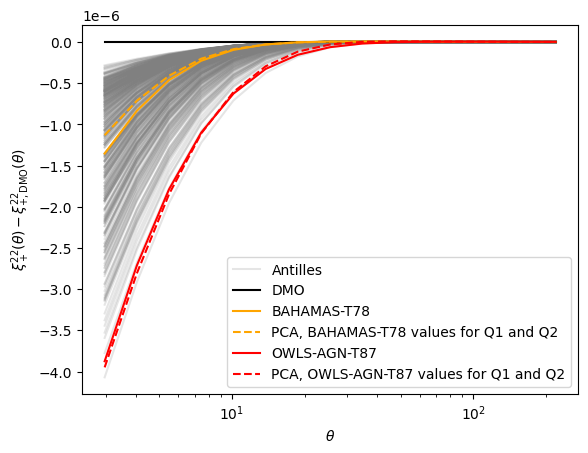

In [109]:
# Plot only (2, 2), difference between Antilles and DMO, recover dv_bahamas and dv_owls with PCA
for i, dv in enumerate(dvs_antilles):
    dv_antilles_22 = dv[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
    plt.semilogx(theta, dv_antilles_22 - dv_nobaryons_22, color="gray", alpha=0.2, label="Antilles" if i == 0 else "")
plt.semilogx(theta, dv_nobaryons_22 - dv_nobaryons_22, color="black", label="DMO")

# Using BAHAMAS values for Q1 and Q2
Q_bahamas_only12 = [Q_bahamas[0, 0], Q_bahamas[0, 1], 0, 0]
dv_bahamas_reconstructed = pca.inverse_transform([Q_bahamas_only12, ])
dv_bahamas_reconstructed_22 = dv_bahamas_reconstructed[0, 2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]

plt.semilogx(theta, dv_bahamas_22 - dv_nobaryons_22, color="orange", label="BAHAMAS-T78")
plt.semilogx(theta, dv_bahamas_reconstructed_22, color="orange", ls="--", label="PCA, BAHAMAS-T78 values for Q1 and Q2")

# Using OWLS-AGN values for Q1 and Q2
Q_owls_only12 = [Q_owls[0, 0], Q_owls[0, 1], 0, 0]
dv_owls_reconstructed = pca.inverse_transform([Q_owls_only12, ])
dv_owls_reconstructed_22 = dv_owls_reconstructed[0, 2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]

plt.semilogx(theta, dv_owls_22 - dv_nobaryons_22, color="red", label="OWLS-AGN-T87")
plt.semilogx(theta, dv_owls_reconstructed_22, color="red", ls="--", label="PCA, OWLS-AGN-T87 values for Q1 and Q2")

plt.xlabel("$\\theta$")
plt.ylabel("$\\xi^{22}_+(\\theta) - \\xi^{22}_{+, \\mathrm{DMO}}(\\theta)$")
plt.legend()

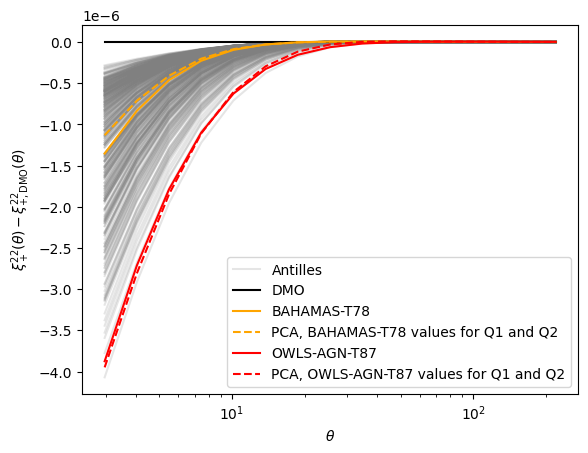

In [113]:
# Plot only (2, 2), difference between Antilles and DMO, recover dv_bahamas and dv_owls with PCA, now do inverse_transform manually

PCs = pca.components_

for i, dv in enumerate(dvs_antilles):
    dv_antilles_22 = dv[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
    plt.semilogx(theta, dv_antilles_22 - dv_nobaryons_22, color="gray", alpha=0.2, label="Antilles" if i == 0 else "")
plt.semilogx(theta, dv_nobaryons_22 - dv_nobaryons_22, color="black", label="DMO")

# Using BAHAMAS values for Q1 and Q2
dv_bahamas_reconstructed = Q_bahamas[0, 0] * PCs[0] + Q_bahamas[0, 1]*PCs[1]
dv_bahamas_reconstructed_22 = dv_bahamas_reconstructed[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]

plt.semilogx(theta, dv_bahamas_22 - dv_nobaryons_22, color="orange", label="BAHAMAS-T78")
plt.semilogx(theta, dv_bahamas_reconstructed_22, color="orange", ls="--", label="PCA, BAHAMAS-T78 values for Q1 and Q2")

# Using OWLS-AGN values for Q1 and Q2
dv_owls_reconstructed = Q_owls[0, 0] * PCs[0] + Q_owls[0, 1]*PCs[1]
dv_owls_reconstructed_22 = dv_owls_reconstructed[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]

plt.semilogx(theta, dv_owls_22 - dv_nobaryons_22, color="red", label="OWLS-AGN-T87")
plt.semilogx(theta, dv_owls_reconstructed_22, color="red", ls="--", label="PCA, OWLS-AGN-T87 values for Q1 and Q2")

plt.xlabel("$\\theta$")
plt.ylabel("$\\xi^{22}_+(\\theta) - \\xi^{22}_{+, \\mathrm{DMO}}(\\theta)$")
plt.legend()

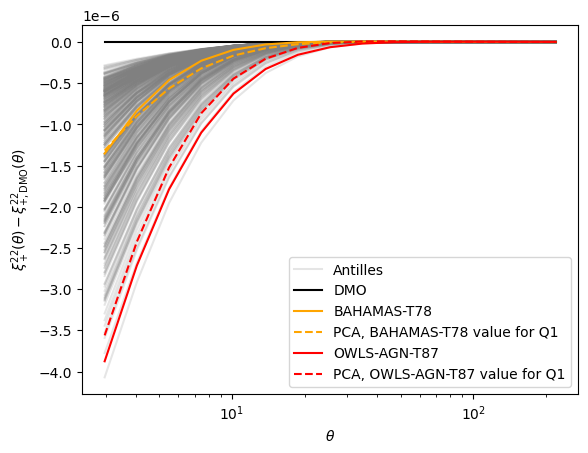

In [119]:
# Plot only (2, 2), difference between Antilles and DMO, recover dv_bahamas and dv_owls with PCA, now do inverse_transform manually

PCs = pca.components_

for i, dv in enumerate(dvs_antilles):
    dv_antilles_22 = dv[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]
    plt.semilogx(theta, dv_antilles_22 - dv_nobaryons_22, color="gray", alpha=0.2, label="Antilles" if i == 0 else "")
plt.semilogx(theta, dv_nobaryons_22 - dv_nobaryons_22, color="black", label="DMO")

# Using BAHAMAS values for Q1 and Q2
dv_bahamas_reconstructed = Q_bahamas[0, 0] * PCs[0]
dv_bahamas_reconstructed_22 = dv_bahamas_reconstructed[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]

plt.semilogx(theta, dv_bahamas_22 - dv_nobaryons_22, color="orange", label="BAHAMAS-T78")
plt.semilogx(theta, dv_bahamas_reconstructed_22, color="orange", ls="--", label="PCA, BAHAMAS-T78 value for Q1")

# Using OWLS-AGN values for Q1 and Q2
dv_owls_reconstructed = Q_owls[0, 0] * PCs[0]
dv_owls_reconstructed_22 = dv_owls_reconstructed[2*NUM_ANG_BINS:(2+1)*NUM_ANG_BINS]

plt.semilogx(theta, dv_owls_22 - dv_nobaryons_22, color="red", label="OWLS-AGN-T87")
plt.semilogx(theta, dv_owls_reconstructed_22, color="red", ls="--", label="PCA, OWLS-AGN-T87 value for Q1")

plt.xlabel("$\\theta$")
plt.ylabel("$\\xi^{22}_+(\\theta) - \\xi^{22}_{+, \\mathrm{DMO}}(\\theta)$")
plt.legend()

In [ ]:
# Saving PCs file
data = PCs.T

# Padding for Cosmolike
for _ in range(2115 - len(data)): data = np.concatenate((data, [[0, 0, 0, 0]]))

np.savetxt("BARYON_PCA_ANTILLES.txt", data)

In [121]:
print(Q_bahamas)

[[-6.37808439e-05  1.25469881e-05  2.15450876e-06 -1.99965621e-07]]
